In [1]:
import torch
torch.cuda.is_available()

True

In [2]:
# Graph aesthetics settings
import matplotlib.pyplot as plt
from cycler import cycler
import seaborn as sns
large = 20; medium = 16; small = 12
colors = ['#66bb6a', '#558ed5', '#dd6a63', '#dcd0ff', '#ffa726', '#8c5eff', '#f44336', '#00bcd4', '#ffc107', '#9c27b0']
text_color = "#404040"

params = {'axes.titlesize': medium,
          'legend.fontsize': small,
          'figure.figsize': (16, 16),
          'axes.labelsize': small,
          'axes.linewidth': 2,
          'xtick.labelsize': small,
          'xtick.color': text_color,
          'ytick.color': text_color,
          'ytick.labelsize': small,
          'axes.edgecolor': text_color,
          'figure.titlesize': small,
          'axes.prop_cycle': cycler(color=colors),
          'axes.titlecolor': text_color,
          'axes.labelcolor': text_color,
         }

plt.rcParams.update(params)

In [3]:
import torch
import numpy as np
from neurodiffeq import diff      
from neurodiffeq.ode import solve 
from neurodiffeq.conditions import IVP 
from neurodiffeq.networks import FCNN
from neurodiffeq.solvers import Solver1D
from neurodiffeq.generators import Generator1D

C:\Users\laksh\anaconda3\envs\torch\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [4]:
def plot_loss(solver):
    history = solver.metrics_history
    plt.figure(figsize=(8,5))
    plt.plot(np.log10(history['train_loss']), label = 'Train')
    
    # Add axis labels, title and legend for clarity
    plt.title('Loss plot')
    plt.xlabel('epochs')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_results(solver):
    history = solver.metrics_history
    t_vals = np.linspace(solver.t_min, solver.t_max, 1000)
    u_pred = solver.get_solution()(t_vals, to_numpy=True)
    plt.figure(figsize=(8,5))
    #plt.plot(t_vals, [np.sin(i) for i in t_vals], c = colors[1])
    plt.plot(t_vals, u_pred, '--', c = colors[0])
    
    # Add axis labels and title for clarity
    plt.title(f'Neural Network approximation at {len(history["train_loss"])} epochs.')
    plt.xlabel('u')
    plt.ylabel('t')
    plt.grid(True)
    plt.show()

In [5]:
def harmonic_oscillator(u, t):
    print(u, t)
    return [diff(u, t, order=2) + 16*torch.pi**2*torch.sin(u)]
init_val_ho = [IVP(t_0=0.0, u_0=0.0, u_0_prime=1.0)]
nets = [FCNN(n_input_units=1, n_output_units=1, hidden_units=[32, 32, 32])]#, 32, 32])]
t_min = 0
t_max = 1
train_g = Generator1D(256, t_min, t_max , method='equally-spaced-noisy')
valid_g = Generator1D(64, t_min, t_max , method='uniform')
optimizer = torch.optim.Adam([p for net in nets for p in net.parameters()],lr = 1e-2)

In [6]:
solver = Solver1D(ode_system=harmonic_oscillator, 
                    conditions=init_val_ho, 
                    t_min=t_min, 
                    t_max=t_max,
                    n_batches_valid=0,
                    train_generator=train_g,
                    valid_generator=valid_g,
                    optimizer=optimizer,
                    nets = nets)

Training Progress:   0%|                                                                         | 0/1 [00:00<…

tensor([[-1.0315e-03],
        [ 4.2678e-03],
        [ 7.8185e-03],
        [ 1.1917e-02],
        [ 1.7288e-02],
        [ 1.8481e-02],
        [ 2.4611e-02],
        [ 2.7168e-02],
        [ 3.1038e-02],
        [ 3.6041e-02],
        [ 4.0343e-02],
        [ 4.0770e-02],
        [ 4.7547e-02],
        [ 5.1854e-02],
        [ 5.4228e-02],
        [ 5.8075e-02],
        [ 6.2885e-02],
        [ 6.8524e-02],
        [ 7.1957e-02],
        [ 7.5459e-02],
        [ 7.9130e-02],
        [ 8.3021e-02],
        [ 8.7224e-02],
        [ 8.8430e-02],
        [ 9.4986e-02],
        [ 9.7867e-02],
        [ 1.0391e-01],
        [ 1.0714e-01],
        [ 1.1147e-01],
        [ 1.1373e-01],
        [ 1.1990e-01],
        [ 1.2074e-01],
        [ 1.2737e-01],
        [ 1.3120e-01],
        [ 1.3519e-01],
        [ 1.3881e-01],
        [ 1.4183e-01],
        [ 1.4710e-01],
        [ 1.4964e-01],
        [ 1.5305e-01],
        [ 1.5776e-01],
        [ 1.6280e-01],
        [ 1.6474e-01],
        [ 1

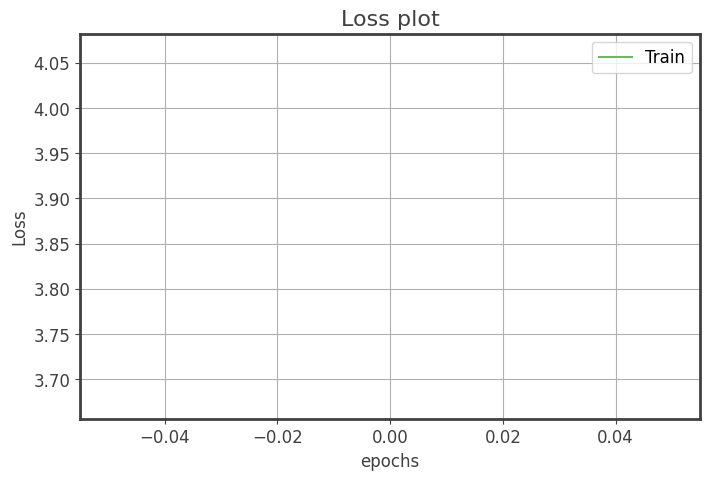

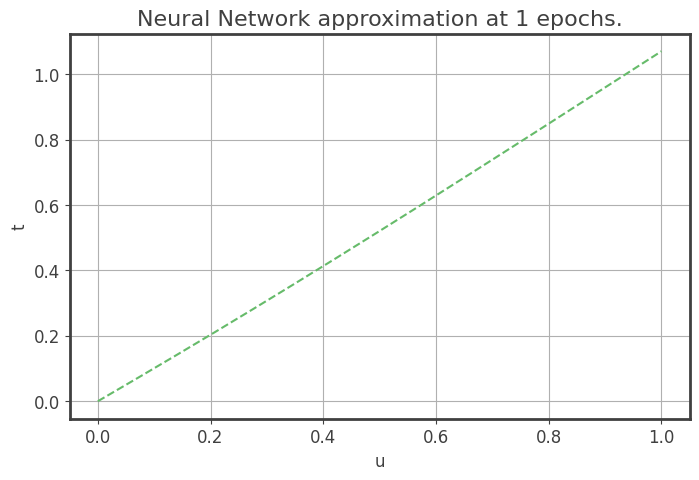

In [7]:
solver.fit(max_epochs=1)
plot_loss(solver)
plot_results(solver)

In [8]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

num_params = count_parameters(nets[0])
print(f'Total number of parameters: {num_params}')

Total number of parameters: 2209
